In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import scipy.stats as stats
import edhec_risk_kit as erk
import matplotlib.pyplot as plt
import streamlit as st

# Fetch S&P 500 daily data from 2000 to end of 2024
ticker = "^GSPC"
df = yf.download(ticker, start="2000-01-01", end="2025-01-01")['Close']

# Calculate log returns
returns = np.log(df / df.shift(1)).dropna()

[*********************100%***********************]  1 of 1 completed


In [2]:
sector_tickers = ['XLK', 'XLF', 'XLE', 'XLV', 'XLU']
df_sectors = yf.download(sector_tickers, start="2006-01-01", end="2010-12-31")['Close']
df_sectors.head()
# Calculate daily log returns across sectors
#sector_returns = np.log(df_sectors / df_sectors.shift(1)).dropna()

[*********************100%***********************]  5 of 5 completed


Ticker,XLE,XLF,XLK,XLU,XLV
Date,,,,,
2006-01-03,14.491588,17.432764,8.211327,7.902344,22.597067
2006-01-04,14.532837,17.416519,8.307657,7.914689,22.822260
2006-01-05,14.348603,17.476072,8.346192,7.862831,22.765953
2006-01-06,14.700583,17.578936,8.477203,7.946794,22.913750
2006-01-09,14.684076,17.627661,8.504174,7.897403,23.019308


In [3]:
rets = df_sectors.pct_change().dropna()
rets.index = pd.to_datetime(rets.index, dayfirst=True)
rets.index=rets.index.to_period('M')
rets.head()
n = rets.shape[0]
n

1257

<Axes: xlabel='Date'>

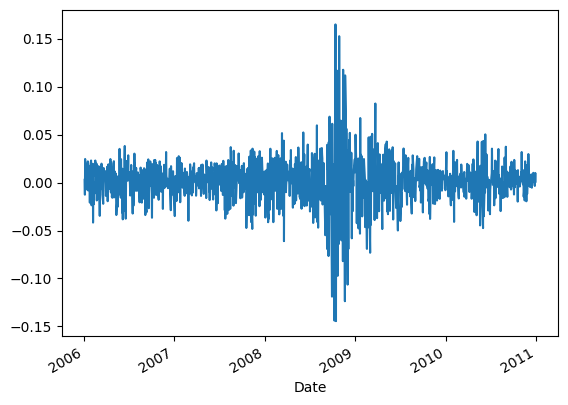

In [18]:
rets["XLE"].plot()

In [20]:
erk.summary_stats(rets)

,Annualized Return,Annualized Vol,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
Ticker,,,,,,,,
XLE,0.003180,0.080285,-0.124018,11.578689,0.000628,0.055035,-0.334061,-0.573594
XLF,-0.005519,0.100889,0.439886,10.959199,0.001766,0.070306,-0.352065,-0.826865
XLK,0.002161,0.055054,0.408673,12.400339,0.000182,0.038203,-0.505666,-0.530359
XLU,0.001533,0.048236,0.738839,14.967139,-0.000616,0.032960,-0.590163,-0.464810
XLV,0.000676,0.040964,0.141554,18.623590,-0.001215,0.028108,-0.715866,-0.391703


In [41]:
dates=rets.index
norm_arr = np.random.normal(size=n)
norm_rets = pd.DataFrame({
    "Dates": dates,
    "Normal Returns": norm_arr
})

In [43]:
norm_rets.head()

,Dates,Normal Returns
0,2006-01,-0.560476
1,2006-01,-0.230499
2,2006-01,0.259705
3,2006-01,1.064520
4,2006-01,-0.588473


<Axes: ylabel='Frequency'>

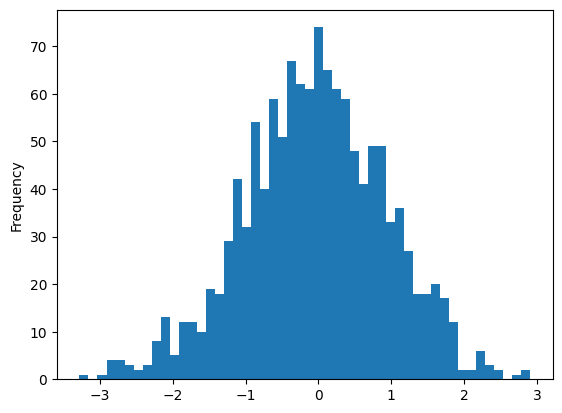

In [44]:
norm_rets['Normal Returns'].plot(kind='hist', bins=50)

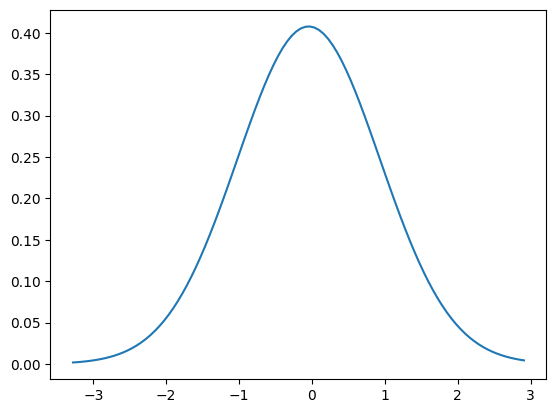

In [58]:
data = norm_rets["Normal Returns"]
mu = data.mean()
sig = data.std(ddof=0)
xn = np.linspace(data.min(), data.max(), 100)
yn = stats.norm.pdf(xn, mu, sig)
norm_plot =plt.plot(xn, yn)

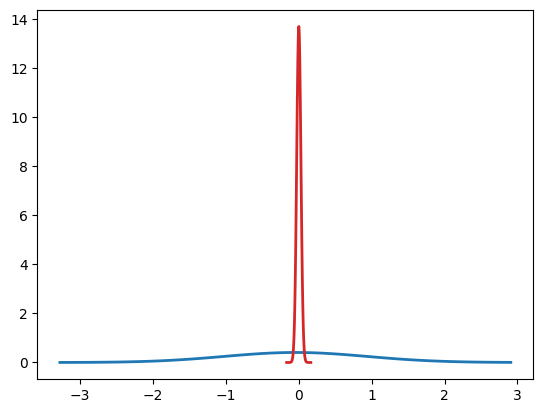

In [59]:
data = rets["XLF"]
mu = data.mean()
sig = data.std(ddof=0)
xr = np.linspace(data.min(), data.max(), 100)
yr = stats.norm.pdf(xr, mu, sig)
plt.plot(xn, yn, label='Synthetic Normal', color='tab:blue', linewidth=2)
plt.plot(xr, yr, label='XLF Returns', color='tab:red', linewidth=2)

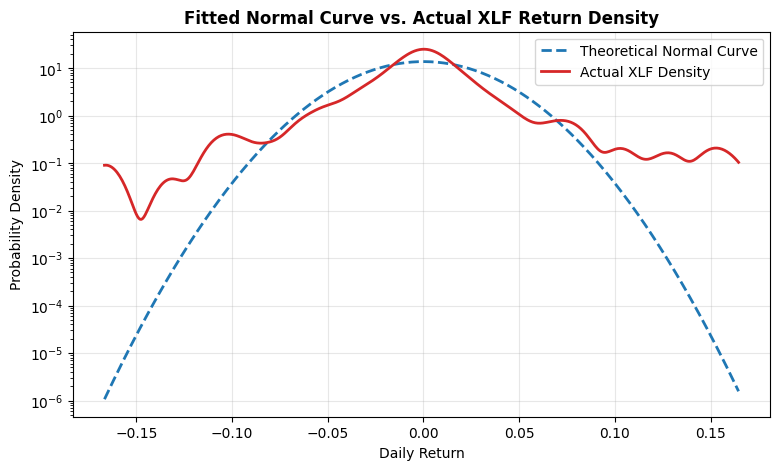

In [70]:
data = rets['XLF'].dropna()
ndata=norm_rets["Normal Returns"]
mu = data.mean()
sig = data.std()

# 1. Create a common x-axis grid matching your return range
x = np.linspace(data.min(), data.max(), 500)

# 2. Line 1: Theoretical Fitted Normal Curve
y_theoretical = stats.norm.pdf(x, mu, sig)

# 3. Line 2: Actual Empirical Density Curve (Smooth line of real data)
kde = stats.gaussian_kde(data)
y_empirical = kde(x)

# 4. Plot both curves on the same axes
plt.figure(figsize=(9, 5))
plt.plot(x, y_theoretical, label='Theoretical Normal Curve', color='tab:blue', linestyle='--', linewidth=2)
plt.plot(x, y_empirical, label='Actual XLF Density', color='tab:red', linewidth=2)

plt.title("Fitted Normal Curve vs. Actual XLF Return Density", fontsize=12, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Probability Density")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.yscale('log')

plt.show()

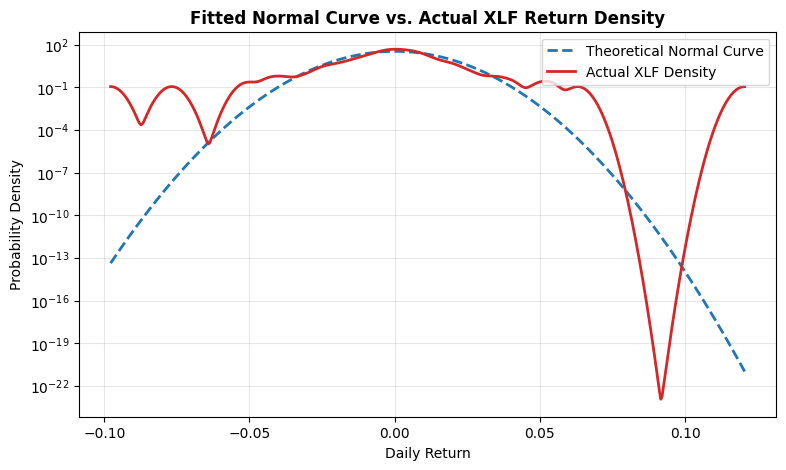

In [69]:
data = rets['XLV'].dropna()
mu = data.mean()
sig = data.std()

# 1. Create a common x-axis grid matching your return range
x = np.linspace(data.min(), data.max(), 500)

# 2. Line 1: Theoretical Fitted Normal Curve
y_theoretical = stats.norm.pdf(x, mu, sig)

# 3. Line 2: Actual Empirical Density Curve (Smooth line of real data)
kde = stats.gaussian_kde(data)
y_empirical = kde(x)

# 4. Plot both curves on the same axes
plt.figure(figsize=(9, 5))
plt.plot(x, y_theoretical, label='Theoretical Normal Curve', color='tab:blue', linestyle='--', linewidth=2)
plt.plot(x, y_empirical, label='Actual XLF Density', color='tab:red', linewidth=2)

plt.title("Fitted Normal Curve vs. Actual XLF Return Density", fontsize=12, fontweight='bold')
plt.xlabel("Daily Return")
plt.ylabel("Probability Density")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.yscale('log')


plt.show()

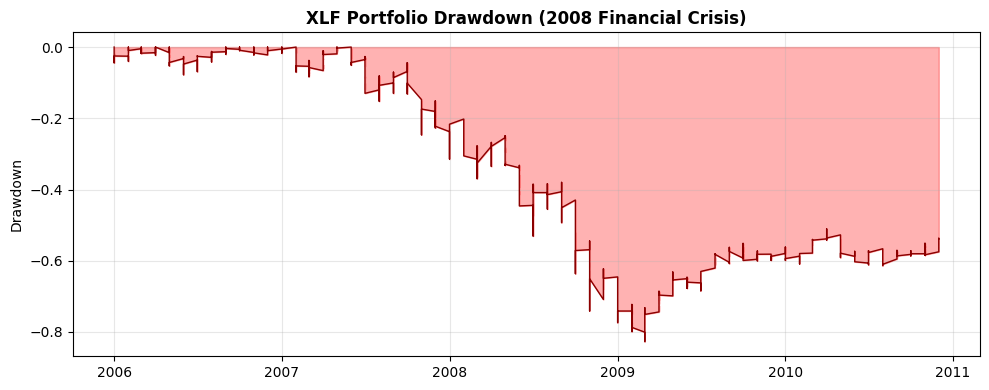

In [83]:
# 1. Get the XLF returns
xlf_rets = rets['XLF'].dropna()

# 2. Convert PeriodIndex to DatetimeIndex
xlf_rets.index = xlf_rets.index.to_timestamp()

# 3. Calculate drawdown using your risk kit
dd = erk.drawdown(xlf_rets)["Drawdown"]

# 4. Plot both line and underwater shading
plt.figure(figsize=(10, 4))
plt.plot(dd.index, dd, color='darkred', linewidth=1)
plt.fill_between(dd.index, 0, dd, color='red', alpha=0.3)

plt.title("XLF Portfolio Drawdown (2008 Financial Crisis)", fontsize=12, fontweight='bold')
plt.ylabel("Drawdown")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: xlabel='Date'>

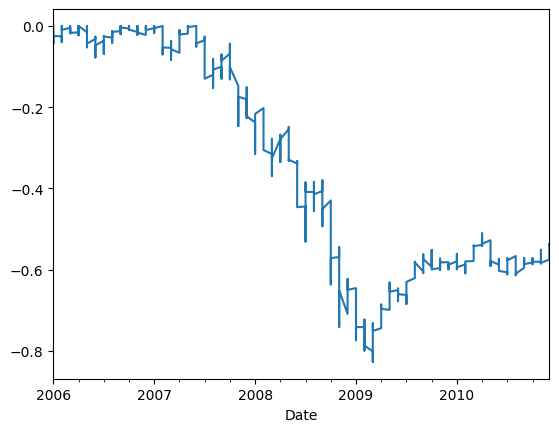

In [79]:
erk.drawdown(data)["Drawdown"].plot()

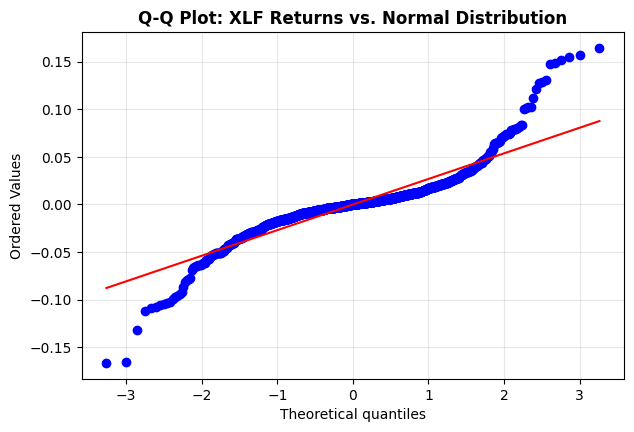

In [84]:
plt.figure(figsize=(7, 4.5))
stats.probplot(xlf_rets, dist="norm", plot=plt)
plt.title("Q-Q Plot: XLF Returns vs. Normal Distribution", fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

In [3]:
r=erk.get_xlf_returns()
r.head()

[*********************100%***********************]  5 of 5 completed


Date
2006-01   -0.000932
2006-01    0.003419
2006-01    0.005886
2006-01    0.002772
2006-01    0.000921
Freq: M, Name: XLF, dtype: float64

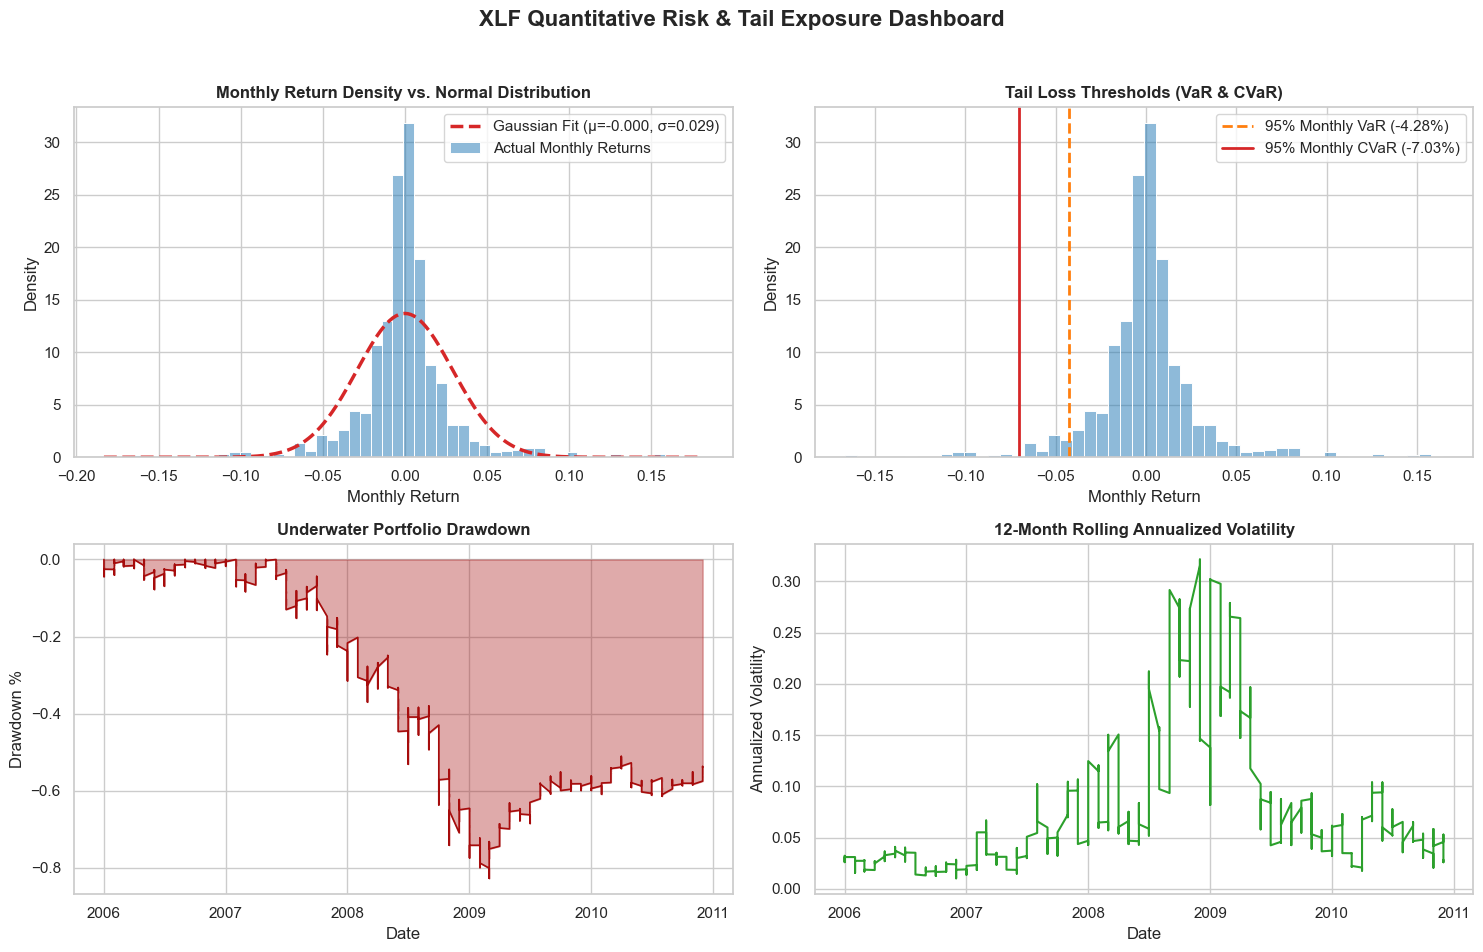

In [8]:
import seaborn as sns

# Set global Seaborn style for a clean look
sns.set_theme(style="whitegrid", font="sans-serif")

# 1. Prepare Data & Metrics
xlf_rets = rets["XLF"].dropna()
if isinstance(xlf_rets.index, pd.PeriodIndex):
    xlf_rets.index = xlf_rets.index.to_timestamp()

# Drawdown Calculation
cum_rets = (1 + xlf_rets).cumprod()
peaks = cum_rets.cummax()
dd = (cum_rets - peaks) / peaks

# VaR and CVaR (95% Level)
conf_level = 0.95
var_5 = xlf_rets.quantile(1 - conf_level)
cvar_5 = xlf_rets[xlf_rets <= var_5].mean()

# 2. Build 2x2 Figure Grid
fig, axes = plt.subplots(2, 2, figsize=(15, 10), dpi=100)
fig.suptitle(
    "XLF Quantitative Risk & Tail Exposure Dashboard",
    fontsize=16,
    fontweight="bold",
    y=0.95,
)

# COLOR PALETTE DEFINITION
NAVY = "#1f77b4"
GAUSS_RED = "#d62728"
VAR_ORANGE = "#ff7f0e"
CVAR_RED = "#d62728"
DD_COLOR = "#a60c0c"
VOL_GREEN = "#2ca02c"

# --- Panel 1: Empirical Return Density vs. Gaussian Overlay ---
sns.histplot(
    xlf_rets,
    bins=50,
    stat="density",
    color=NAVY,
    alpha=0.5,
    edgecolor="white",
    ax=axes[0, 0],
    label="Actual Monthly Returns",
)

# Fit Gaussian Curve
mu, std = stats.norm.fit(xlf_rets)
xmin, xmax = axes[0, 0].get_xlim()
x_axis = np.linspace(xmin, xmax, 200)
p_gaussian = stats.norm.pdf(x_axis, mu, std)

axes[0, 0].plot(
    x_axis,
    p_gaussian,
    color=GAUSS_RED,
    linestyle="--",
    linewidth=2.5,
    label=f"Gaussian Fit (μ={mu:.3f}, σ={std:.3f})",
)
axes[0, 0].set_title(
    "Monthly Return Density vs. Normal Distribution",
    fontweight="bold",
    fontsize=12,
)
axes[0, 0].set_xlabel("Monthly Return")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(frameon=True)

# --- Panel 2: Tail Loss Distribution (95% VaR & CVaR Cutoffs) ---
sns.histplot(
    xlf_rets,
    bins=50,
    stat="density",
    color=NAVY,
    alpha=0.5,
    edgecolor="white",
    ax=axes[0, 1],
)
axes[0, 1].axvline(
    var_5,
    color=VAR_ORANGE,
    linestyle="--",
    linewidth=2,
    label=f"95% Monthly VaR ({var_5:.2%})",
)
axes[0, 1].axvline(
    cvar_5,
    color=CVAR_RED,
    linestyle="-",
    linewidth=2,
    label=f"95% Monthly CVaR ({cvar_5:.2%})",
)
axes[0, 1].set_title(
    "Tail Loss Thresholds (VaR & CVaR)", fontweight="bold", fontsize=12
)
axes[0, 1].set_xlabel("Monthly Return")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend(frameon=True)

# --- Panel 3: Underwater Drawdown Chart ---
axes[1, 0].plot(dd.index, dd, color=DD_COLOR, linewidth=1.2)
axes[1, 0].fill_between(dd.index, 0, dd, color=DD_COLOR, alpha=0.35)
axes[1, 0].set_title("Underwater Portfolio Drawdown", fontweight="bold", fontsize=12)
axes[1, 0].set_ylabel("Drawdown %")
axes[1, 0].set_xlabel("Date")

# --- Panel 4: 12-Month Rolling Annualized Volatility ---
roll_vol = xlf_rets.rolling(12).std() * np.sqrt(12)
axes[1, 1].plot(roll_vol.index, roll_vol, color=VOL_GREEN, linewidth=1.5)
axes[1, 1].set_title(
    "12-Month Rolling Annualized Volatility", fontweight="bold", fontsize=12
)
axes[1, 1].set_ylabel("Annualized Volatility")
axes[1, 1].set_xlabel("Date")

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
import seaborn as sns

# Set global Seaborn style
sns.set_theme(style="whitegrid", font="sans-serif")

# 1. Prepare Data & Metrics
xlf_rets = rets["XLF"].dropna()
if isinstance(xlf_rets.index, pd.PeriodIndex):
    xlf_rets.index = xlf_rets.index.to_timestamp()

# Drawdown Calculation
cum_rets = (1 + xlf_rets).cumprod()
peaks = cum_rets.cummax()
dd = (cum_rets - peaks) / peaks

# --- RISK METRICS CALCULATIONS (95% Confidence) ---
conf_level = 0.95
alpha = 1 - conf_level

# Empirical (Historical) Risk Metrics
emp_var = xlf_rets.quantile(alpha)
emp_cvar = xlf_rets[xlf_rets <= emp_var].mean()

# Parametric (Gaussian Normal) Risk Metrics
mu, std = stats.norm.fit(xlf_rets)
gauss_var = stats.norm.ppf(alpha, loc=mu, scale=std)

# Analytical Gaussian CVaR formula: mu - std * (pdf(z) / alpha)
z_score = stats.norm.ppf(alpha)
gauss_cvar = mu - std * (stats.norm.pdf(z_score) / alpha)

# Print Summary Comparison in Terminal
print(f"--- 95% MONTHLY RISK COMPARISON ---")
print(f"Empirical VaR:  {emp_var:.2%}  |  Gaussian VaR:  {gauss_var:.2%}")
print(f"Empirical CVaR: {emp_cvar:.2%}  |  Gaussian CVaR: {gauss_cvar:.2%}")

# 2. Build 2x2 Figure Grid
fig, axes = plt.subplots(2, 2, figsize=(16, 11), dpi=100)
fig.suptitle(
    "XLF Quantitative Risk & Tail Exposure Dashboard",
    fontsize=16,
    fontweight="bold",
    y=0.96,
)

# COLOR PALETTE DEFINITION
NAVY = "#1f77b4"
GAUSS_RED = "#d62728"
EMP_VAR_COLOR = "#ff7f0e"  # Orange
EMP_CVAR_COLOR = "#d62728"  # Red
GAUSS_VAR_COLOR = "#9467bd"  # Purple
GAUSS_CVAR_COLOR = "#8c564b"  # Brown
DD_COLOR = "#a60c0c"
VOL_GREEN = "#2ca02c"

# --- Panel 1: Return Density vs. Gaussian Fit with Risk Lines ---
sns.histplot(
    xlf_rets,
    bins=50,
    stat="density",
    color=NAVY,
    alpha=0.4,
    edgecolor="white",
    ax=axes[0, 0],
    label="Actual Monthly Returns",
)

# Gaussian Curve Overlay
xmin, xmax = axes[0, 0].get_xlim()
x_axis = np.linspace(xmin, xmax, 200)
p_gaussian = stats.norm.pdf(x_axis, mu, std)

axes[0, 0].plot(
    x_axis,
    p_gaussian,
    color=GAUSS_RED,
    linestyle="--",
    linewidth=2.5,
    label=f"Gaussian Fit (μ={mu:.3f}, σ={std:.3f})",
)

# Gaussian Risk Overlays on Panel 1
axes[0, 0].axvline(
    gauss_var,
    color=GAUSS_VAR_COLOR,
    linestyle=":",
    linewidth=2,
    label=f"Gaussian 95% VaR ({gauss_var:.2%})",
)
axes[0, 0].axvline(
    gauss_cvar,
    color=GAUSS_CVAR_COLOR,
    linestyle="-.",
    linewidth=2,
    label=f"Gaussian 95% CVaR ({gauss_cvar:.2%})",
)

axes[0, 0].set_title(
    "Return Density & Gaussian Fit",
    fontweight="bold",
    fontsize=12,
)
axes[0, 0].set_xlabel("Monthly Return")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend(frameon=True, fontsize=9)

# --- Panel 2: Empirical vs. Gaussian Tail Risk Comparison ---
sns.histplot(
    xlf_rets,
    bins=50,
    stat="density",
    color=NAVY,
    alpha=0.3,
    edgecolor="white",
    ax=axes[0, 1],
)

# Plot Empirical Risk Cutoffs
axes[0, 1].axvline(
    emp_var,
    color=EMP_VAR_COLOR,
    linestyle="--",
    linewidth=2,
    label=f"Empirical 95% VaR ({emp_var:.2%})",
)
axes[0, 1].axvline(
    emp_cvar,
    color=EMP_CVAR_COLOR,
    linestyle="-",
    linewidth=2,
    label=f"Empirical 95% CVaR ({emp_cvar:.2%})",
)

axes[0, 1].set_title(
    "Tail Risk Comparison: Empirical vs. Gaussian",
    fontweight="bold",
    fontsize=12,
)
axes[0, 1].set_xlabel("Monthly Return")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend(frameon=True, fontsize=9)

# --- Panel 3: Underwater Drawdown Chart ---
axes[1, 0].plot(dd.index, dd, color=DD_COLOR, linewidth=1.2)
axes[1, 0].fill_between(dd.index, 0, dd, color=DD_COLOR, alpha=0.35)
axes[1, 0].set_title("Underwater Portfolio Drawdown", fontweight="bold", fontsize=12)
axes[1, 0].set_ylabel("Drawdown %")
axes[1, 0].set_xlabel("Date")

# --- Panel 4: 12-Month Rolling Annualized Volatility ---
roll_vol = xlf_rets.rolling(12).std() * np.sqrt(12)
axes[1, 1].plot(roll_vol.index, roll_vol, color=VOL_GREEN, linewidth=1.5)
axes[1, 1].set_title(
    "12-Month Rolling Annualized Volatility", fontweight="bold", fontsize=12
)
axes[1, 1].set_ylabel("Annualized Volatility")
axes[1, 1].set_xlabel("Date")

plt.tight_layout(rect=[0, 0, 1, 0.94])
#plt.savefig("XLF_Risk_Dashboard.png", dpi=300, bbox_inches="tight")
plt.show()